<a href="https://colab.research.google.com/github/amanbhatia-analyst/early-diabetes-detection-project/blob/main/early%20diabetes%20detection%20code%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset (adjust the file path if needed)
df = pd.read_csv('diabetes.csv')

# Display the first few rows
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
from sklearn.preprocessing import StandardScaler

# Check for missing values
print(df.isnull().sum())

# If there are missing values (e.g., 0 for certain columns), we can replace them
# Replace zeros with NaN for the specific columns if needed (if they represent missing data)
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, pd.NA)

# Fill missing values with the median (a common practice)
df.fillna(df.median(), inplace=True)

# Feature scaling using StandardScaler
scaler = StandardScaler()
numeric_features = df.drop(columns=['Outcome'])  # Drop target variable for scaling
df[numeric_features.columns] = scaler.fit_transform(df[numeric_features.columns])

# Show the scaled data
print(df.head())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.670643 -0.181541  0.166619   
1    -0.844885 -1.205066      -0.528319      -0.012301 -0.181541 -0.852200   
2     1.233880  2.016662      -0.693761      -0.012301 -0.181541 -1.332500   
3    -0.844885 -1.073567      -0.528319      -0.695245 -0.540642 -0.633881   
4    -1.141852  0.504422      -2.679076       0.670643  0.316566  1.549303   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.468492  1.425995        1  
1                 -0.365061 -0.190672        0  
2                  0.604397 -0.105584        1  
3                 -0.920763 -1.041549        0  
4  

<ipython-input-2-01b43a6be3b5>:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(df.median(), inplace=True)


In [ ]:
X = df.drop(columns=['Outcome'])  # Features (everything except the target variable)
y = df['Outcome']  # Target variable (diabetes status)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Display the shape of the splits
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(614, 8) (154, 8) (614,) (154,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


In [ ]:
# Initialize and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
# Make predictions
y_pred = model.predict(X_test)


In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')


Accuracy: 75.32%


In [ ]:
# Display confusion matrix
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[82 17]
 [21 34]]


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Choose one method:
scaler = StandardScaler()  # Standardization (zero mean, unit variance)
# scaler = MinMaxScaler()  # Normalization (0 to 1 range)

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_features] = scaler.fit_transform(df[numeric_features])

print(df.head())  # Check scaled data


   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.670643 -0.181541  0.166619   
1    -0.844885 -1.205066      -0.528319      -0.012301 -0.181541 -0.852200   
2     1.233880  2.016662      -0.693761      -0.012301 -0.181541 -1.332500   
3    -0.844885 -1.073567      -0.528319      -0.695245 -0.540642 -0.633881   
4    -1.141852  0.504422      -2.679076       0.670643  0.316566  1.549303   

   DiabetesPedigreeFunction       Age   Outcome  
0                  0.468492  1.425995  1.365896  
1                 -0.365061 -0.190672 -0.732120  
2                  0.604397 -0.105584  1.365896  
3                 -0.920763 -1.041549 -0.732120  
4                  5.484909 -0.020496  1.365896  


In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)  # One-hot encoding

print(df.head())  # Check transformed dataset


   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.670643 -0.181541  0.166619   
1    -0.844885 -1.205066      -0.528319      -0.012301 -0.181541 -0.852200   
2     1.233880  2.016662      -0.693761      -0.012301 -0.181541 -1.332500   
3    -0.844885 -1.073567      -0.528319      -0.695245 -0.540642 -0.633881   
4    -1.141852  0.504422      -2.679076       0.670643  0.316566  1.549303   

   DiabetesPedigreeFunction       Age   Outcome  
0                  0.468492  1.425995  1.365896  
1                 -0.365061 -0.190672 -0.732120  
2                  0.604397 -0.105584  1.365896  
3                 -0.920763 -1.041549 -0.732120  
4                  5.484909 -0.020496  1.365896  


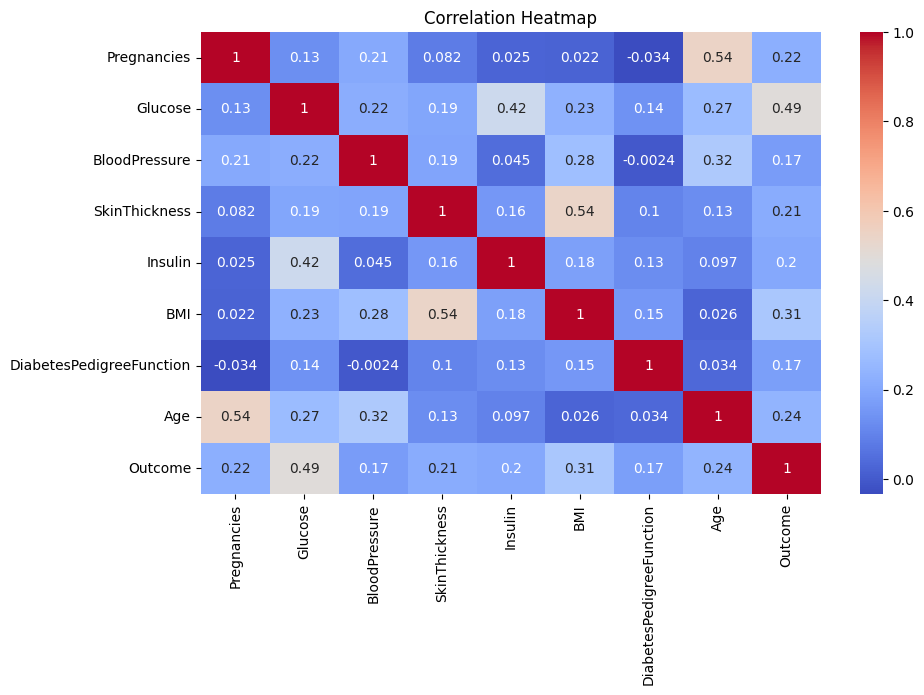

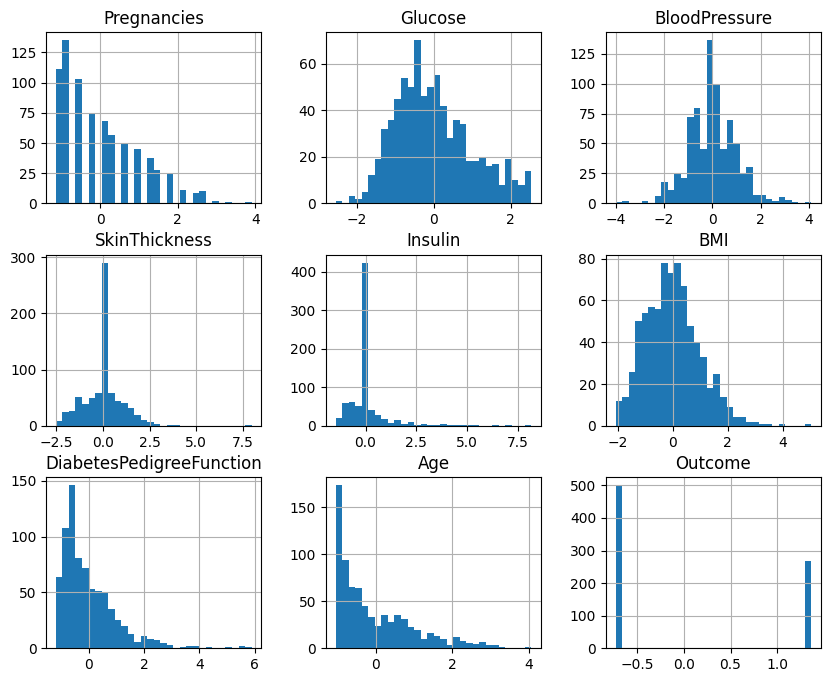

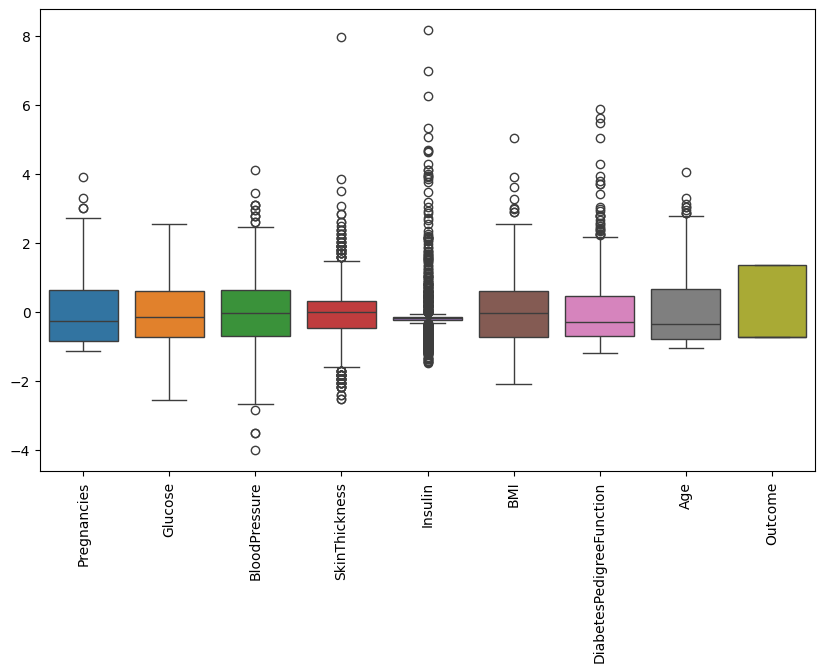

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Histograms
df.hist(figsize=(10, 8), bins=30)
plt.show()

# Box plots (detect outliers)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# Replace 'Outcome' with your actual target column name
X = df.drop(columns=['Outcome'])  # Replace 'Outcome' with your actual target variable name
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")



Training data size: (614, 8)
Testing data size: (154, 8)


In [ ]:
print(df.columns)  # This will display all column names


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [ ]:
print(y_train.head())  # Check the first few rows of the target column
print(y_train.unique())  # Check the unique values in the target column


60    -0.732120
618    1.365896
346   -0.732120
294   -0.732120
231    1.365896
Name: Outcome, dtype: float64
[-0.73212021  1.36589591]


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

# Decision Tree Regressor
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)

# KNN Regressor
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)


KNeighborsRegressor()

In [ ]:
y = df['Outcome'].astype(int)  # Ensuring the target is in integer format


In [ ]:
print("Unique values in y_test:", y_test.unique())



Unique values in y_test: [-0.73212021  1.36589591]


In [ ]:
df['Outcome'] = df['Outcome'].astype(int)  # Convert to integer (0 or 1)


In [ ]:
print("Unique values in y_test:", y_test.unique())  # Check unique values in the target column




Unique values in y_test: [0 1]


In [ ]:
# If your target variable ('Outcome') is in a non-numeric format (like Yes/No or continuous), convert it
df['Outcome'] = df['Outcome'].astype(int)  # Ensuring it's in binary format (0 or 1)


In [ ]:
y = df['Outcome']  # Target variable
X = df.drop(columns=['Outcome'])  # Features (excluding target column)


In [ ]:
print("X shape:", X.shape)  # Should be (num_samples, num_features)
print("y shape:", y.shape)  # Should be (num_samples,)


X shape: (768, 8)
y shape: (768,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")


Training data size: (614, 8)
Testing data size: (154, 8)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Decision Tree Model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


KNeighborsClassifier()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)

# Accuracy Scores
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}")
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")

# Classification Reports
print("\nDecision Tree Report:\n", classification_report(y_test, y_pred_dt))
print("\nKNN Report:\n", classification_report(y_test, y_pred_knn))


Decision Tree Accuracy: 0.70
KNN Accuracy: 0.73

Decision Tree Report:
               precision    recall  f1-score   support

           0       0.78      0.75      0.76        99
           1       0.58      0.62      0.60        55

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154


KNN Report:
               precision    recall  f1-score   support

           0       0.82      0.76      0.79        99
           1       0.61      0.69      0.65        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Decision Tree Predictions
y_pred_dt = dt_model.predict(X_test)

# KNN Predictions
y_pred_knn = knn_model.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_knn = accuracy_score(y_test, y_pred_knn)

# Precision (Class 0)
prec_dt_class0 = precision_score(y_test, y_pred_dt, pos_label=0)
prec_knn_class0 = precision_score(y_test, y_pred_knn, pos_label=0)

# Recall (Class 0)
recall_dt_class0 = recall_score(y_test, y_pred_dt, pos_label=0)
recall_knn_class0 = recall_score(y_test, y_pred_knn, pos_label=0)

# F1-Score (Class 0)
f1_dt_class0 = f1_score(y_test, y_pred_dt, pos_label=0)
f1_knn_class0 = f1_score(y_test, y_pred_knn, pos_label=0)

# Precision (Class 1)
prec_dt_class1 = precision_score(y_test, y_pred_dt, pos_label=1)
prec_knn_class1 = precision_score(y_test, y_pred_knn, pos_label=1)

# Recall (Class 1)
recall_dt_class1 = recall_score(y_test, y_pred_dt, pos_label=1)
recall_knn_class1 = recall_score(y_test, y_pred_knn, pos_label=1)

# F1-Score (Class 1)
f1_dt_class1 = f1_score(y_test, y_pred_dt, pos_label=1)
f1_knn_class1 = f1_score(y_test, y_pred_knn, pos_label=1)

# Print results
print(f"Decision Tree Accuracy: {acc_dt:.2f}")
print(f"KNN Accuracy: {acc_knn:.2f}")

# Insert these values into the table where you have placeholders (like [insert accuracy], etc.)

Decision Tree Accuracy: 0.70
KNN Accuracy: 0.73


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Decision Tree Predictions
y_pred_dt = dt_model.predict(X_test)

# KNN Predictions
y_pred_knn = knn_model.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_knn = accuracy_score(y_test, y_pred_knn)

# Precision (Class 0)
prec_dt_class0 = precision_score(y_test, y_pred_dt, pos_label=0)
prec_knn_class0 = precision_score(y_test, y_pred_knn, pos_label=0)

# Recall (Class 0)
recall_dt_class0 = recall_score(y_test, y_pred_dt, pos_label=0)
recall_knn_class0 = recall_score(y_test, y_pred_knn, pos_label=0)

# F1-Score (Class 0)
f1_dt_class0 = f1_score(y_test, y_pred_dt, pos_label=0)
f1_knn_class0 = f1_score(y_test, y_pred_knn, pos_label=0)

# Precision (Class 1)
prec_dt_class1 = precision_score(y_test, y_pred_dt, pos_label=1)
prec_knn_class1 = precision_score(y_test, y_pred_knn, pos_label=1)

# Recall (Class 1)
recall_dt_class1 = recall_score(y_test, y_pred_dt, pos_label=1)
recall_knn_class1 = recall_score(y_test, y_pred_knn, pos_label=1)

# F1-Score (Class 1)
f1_dt_class1 = f1_score(y_test, y_pred_dt, pos_label=1)
f1_knn_class1 = f1_score(y_test, y_pred_knn, pos_label=1)

# Print results
print(f"Decision Tree Accuracy: {acc_dt:.2f}")
print(f"KNN Accuracy: {acc_knn:.2f}")
print(f"Decision Tree Precision (Class 0): {prec_dt_class0:.2f}")
print(f"KNN Precision (Class 0): {prec_knn_class0:.2f}")
print(f"Decision Tree Recall (Class 0): {recall_dt_class0:.2f}")
print(f"KNN Recall (Class 0): {recall_knn_class0:.2f}")
print(f"Decision Tree F1-Score (Class 0): {f1_dt_class0:.2f}")
print(f"KNN F1-Score (Class 0): {f1_knn_class0:.2f}")
print(f"Decision Tree Precision (Class 1): {prec_dt_class1:.2f}")
print(f"KNN Precision (Class 1): {prec_knn_class1:.2f}")
print(f"Decision Tree Recall (Class 1): {recall_dt_class1:.2f}")
print(f"KNN Recall (Class 1): {recall_knn_class1:.2f}")
print(f"Decision Tree F1-Score (Class 1): {f1_dt_class1:.2f}")
print(f"KNN F1-Score (Class 1): {f1_knn_class1:.2f}")


Decision Tree Accuracy: 0.70
KNN Accuracy: 0.73
Decision Tree Precision (Class 0): 0.78
KNN Precision (Class 0): 0.82
Decision Tree Recall (Class 0): 0.75
KNN Recall (Class 0): 0.76
Decision Tree F1-Score (Class 0): 0.76
KNN F1-Score (Class 0): 0.79
Decision Tree Precision (Class 1): 0.58
KNN Precision (Class 1): 0.61
Decision Tree Recall (Class 1): 0.62
KNN Recall (Class 1): 0.69
Decision Tree F1-Score (Class 1): 0.60
KNN F1-Score (Class 1): 0.65
